In [ ]:
import warnings
warnings.filterwarnings("ignore")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import os

In [ ]:
csv_files = [
    '/content/UNSW_2018_IoT_Botnet_Full5pc_1.csv',
    '/content/UNSW_2018_IoT_Botnet_Full5pc_2.csv',
    '/content/UNSW_2018_IoT_Botnet_Full5pc_3.csv',
    '/content/UNSW_2018_IoT_Botnet_Full5pc_4.csv'
]

In [ ]:
df_list = [pd.read_csv(file) for file in csv_files]
df = pd.concat(df_list, ignore_index=True)

In [ ]:
print("Total rows after concatenation:", len(df))

Total rows after concatenation: 141104


subcategory is my target variable

now we will encode the target variable to know the total count

In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
df = df.dropna(subset=['subcategory'])

In [ ]:
le = LabelEncoder()
df['subcategory_encoded'] = le.fit_transform(df['subcategory'])

In [ ]:
subcat_counts = df['subcategory'].value_counts()
print("These are the classes count after encoding:\n", df['subcategory'].value_counts())

These are the classes count after encoding:
 subcategory
TCP     76917
UDP     62698
HTTP     1485
Name: count, dtype: int64


In [ ]:
rare_classes = subcat_counts[subcat_counts < 100].index
df = df[~df['subcategory'].isin(rare_classes)]

In [ ]:
print("Remaining classes after removing rare ones:\n", df['subcategory'].value_counts())

Remaining classes after removing rare ones:
 subcategory
TCP     76917
UDP     62698
HTTP     1485
Name: count, dtype: int64


now that we have the count we will apply data visualisation techniques to the dataset

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

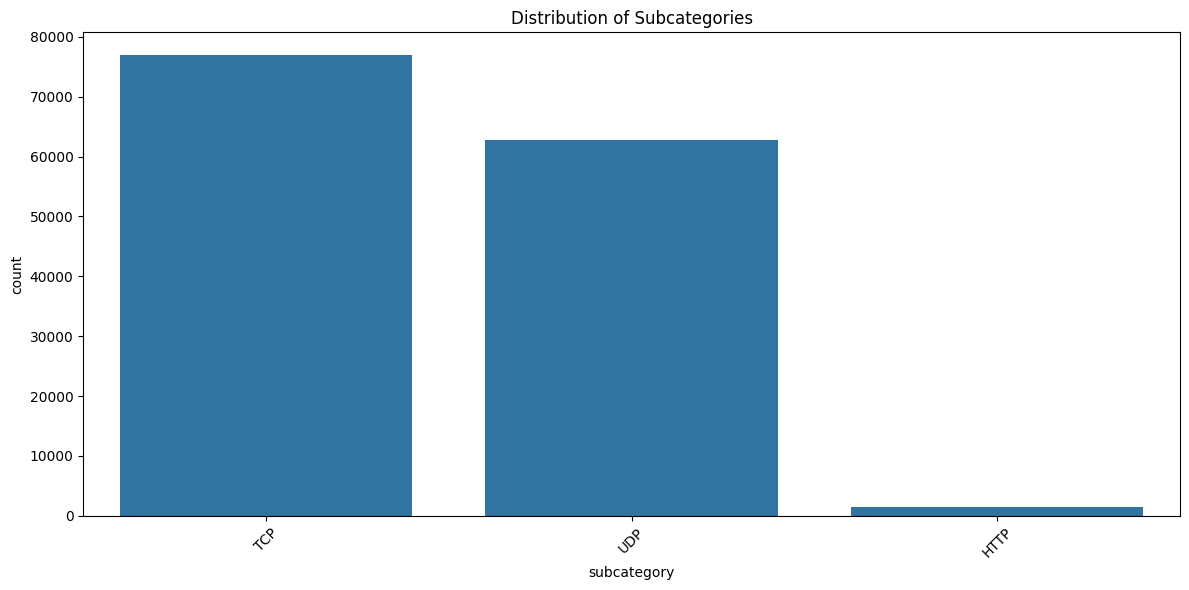

In [ ]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='subcategory', order=df['subcategory'].value_counts().index)
plt.xticks(rotation=45)
plt.title('Distribution of Subcategories')
plt.tight_layout()
plt.show()

In [ ]:
final_size = 101010

In [ ]:
counts = df['subcategory'].value_counts()
print(counts)

subcategory
TCP     76917
UDP     62698
HTTP     1485
Name: count, dtype: int64


In [ ]:
minor_classes = counts[counts < (final_size // len(counts))].index
major_classes = counts[counts >= (final_size // len(counts))].index

In [ ]:
minor_df = df[df['subcategory'].isin(minor_classes)]

In [ ]:
remaining_quota = final_size - len(minor_df)

In [ ]:
major_df_list = []
for label in major_classes:
    class_df = df[df['subcategory'] == label]
    sample_size = int((counts[label] / counts[major_classes].sum()) * remaining_quota)
    major_df_list.append(class_df.sample(n=sample_size, random_state=42))

In [ ]:
final_df = pd.concat([minor_df] + major_df_list, ignore_index=True)

In [ ]:
final_df = final_df.sample(frac=1, random_state=42).reset_index(drop=True)

In [ ]:
print("Final dataset shape:", final_df.shape)

Final dataset shape: (101009, 47)


In [ ]:
final_df.to_csv('bot_iot_100k.csv', index=False)
print("Final dataset saved as 'bot_iot_100k.csv'")

Final dataset saved as 'bot_iot_100k.csv'


In [ ]:
df = pd.read_csv('/content/bot_iot_100k.csv')
df.head()

,pkSeqID,stime,flgs,flgs_number,proto,proto_number,saddr,sport,daddr,dport,...,N_IN_Conn_P_DstIP,N_IN_Conn_P_SrcIP,AR_P_Proto_P_Sport,AR_P_Proto_P_Dport,Pkts_P_State_P_Protocol_P_DestIP,Pkts_P_State_P_Protocol_P_SrcIP,attack,category,subcategory,subcategory_encoded
0,3026760,1.528099e+09,e,1,udp,3,192.168.100.148,12246,192.168.100.3,80,...,100.0,88.0,0.802397,0.837764,1148.0,968.0,1.0,DDoS,UDP,2
1,2026698,1.528096e+09,e s,2,tcp,1,192.168.100.148,11097,192.168.100.3,80,...,100.0,100.0,0.475484,0.423860,434.0,434.0,1.0,DDoS,TCP,1
2,36852,1.528081e+09,e s,2,tcp,1,192.168.100.147,26319,192.168.100.7,80,...,62.0,62.0,0.124956,0.156078,248.0,248.0,1.0,DoS,TCP,1
3,29792,1.528081e+09,e s,2,tcp,1,192.168.100.147,22755,192.168.100.7,80,...,42.0,42.0,0.126278,0.172865,168.0,168.0,1.0,DoS,TCP,1
4,29543,1.528081e+09,e s,2,tcp,1,192.168.100.147,22644,192.168.100.7,80,...,66.0,66.0,0.126260,0.153315,264.0,264.0,1.0,DoS,TCP,1


In [ ]:
print(df.isnull().sum())

pkSeqID                             0
stime                               0
flgs                                0
flgs_number                         0
proto                               0
proto_number                        0
saddr                               0
sport                               0
daddr                               0
dport                               0
pkts                                0
bytes                               0
state                               0
state_number                        0
ltime                               0
seq                                 0
dur                                 0
mean                                0
stddev                              0
sum                                 0
min                                 0
max                                 0
spkts                               0
dpkts                               0
sbytes                              0
dbytes                              0
rate        

In [ ]:
df = df.drop_duplicates()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101009 entries, 0 to 101008
Data columns (total 47 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   pkSeqID                           101009 non-null  int64  
 1   stime                             101009 non-null  float64
 2   flgs                              101009 non-null  object 
 3   flgs_number                       101009 non-null  int64  
 4   proto                             101009 non-null  object 
 5   proto_number                      101009 non-null  int64  
 6   saddr                             101009 non-null  object 
 7   sport                             101009 non-null  int64  
 8   daddr                             101009 non-null  object 
 9   dport                             101009 non-null  int64  
 10  pkts                              101009 non-null  int64  
 11  bytes                             101009 non-null  i

now we will perform encoding


In [ ]:
non_numeric_columns = df.select_dtypes(exclude=['number']).columns
print("Non-numeric columns:")
print(non_numeric_columns.tolist())

Non-numeric columns:
['flgs', 'proto', 'saddr', 'daddr', 'state', 'category', 'subcategory']


In [ ]:
df = df.drop(columns=['subcategory'])

In [ ]:
non_numeric_columns = df.select_dtypes(exclude=['number']).columns
print("Non-numeric columns:")
print(non_numeric_columns.tolist())

Non-numeric columns:
['flgs', 'proto', 'saddr', 'daddr', 'state', 'category']


now lets encode these columns using label encoding

In [ ]:
label_encoder = LabelEncoder()
for col in non_numeric_columns:
    df[col] = label_encoder.fit_transform(df[col])

In [ ]:
df.head()

,pkSeqID,stime,flgs,flgs_number,proto,proto_number,saddr,sport,daddr,dport,...,AR_P_Proto_P_DstIP,N_IN_Conn_P_DstIP,N_IN_Conn_P_SrcIP,AR_P_Proto_P_Sport,AR_P_Proto_P_Dport,Pkts_P_State_P_Protocol_P_DestIP,Pkts_P_State_P_Protocol_P_SrcIP,attack,category,subcategory_encoded
0,3026760,1.528099e+09,0,1,2,3,1,12246,3,80,...,0.837764,100.0,88.0,0.802397,0.837764,1148.0,968.0,1.0,0,2
1,2026698,1.528096e+09,4,2,1,1,1,11097,3,80,...,0.423860,100.0,100.0,0.475484,0.423860,434.0,434.0,1.0,0,1
2,36852,1.528081e+09,4,2,1,1,0,26319,6,80,...,0.124956,62.0,62.0,0.124956,0.156078,248.0,248.0,1.0,1,1
3,29792,1.528081e+09,4,2,1,1,0,22755,6,80,...,0.126278,42.0,42.0,0.126278,0.172865,168.0,168.0,1.0,1,1
4,29543,1.528081e+09,4,2,1,1,0,22644,6,80,...,0.126260,66.0,66.0,0.126260,0.153315,264.0,264.0,1.0,1,1


In [ ]:
subcat_counts = df['subcategory_encoded'].value_counts()
print("Remaining classes after removing rare ones:\n", df['subcategory_encoded'].value_counts())

Remaining classes after removing rare ones:
 subcategory_encoded
1    54830
2    44694
0     1485
Name: count, dtype: int64


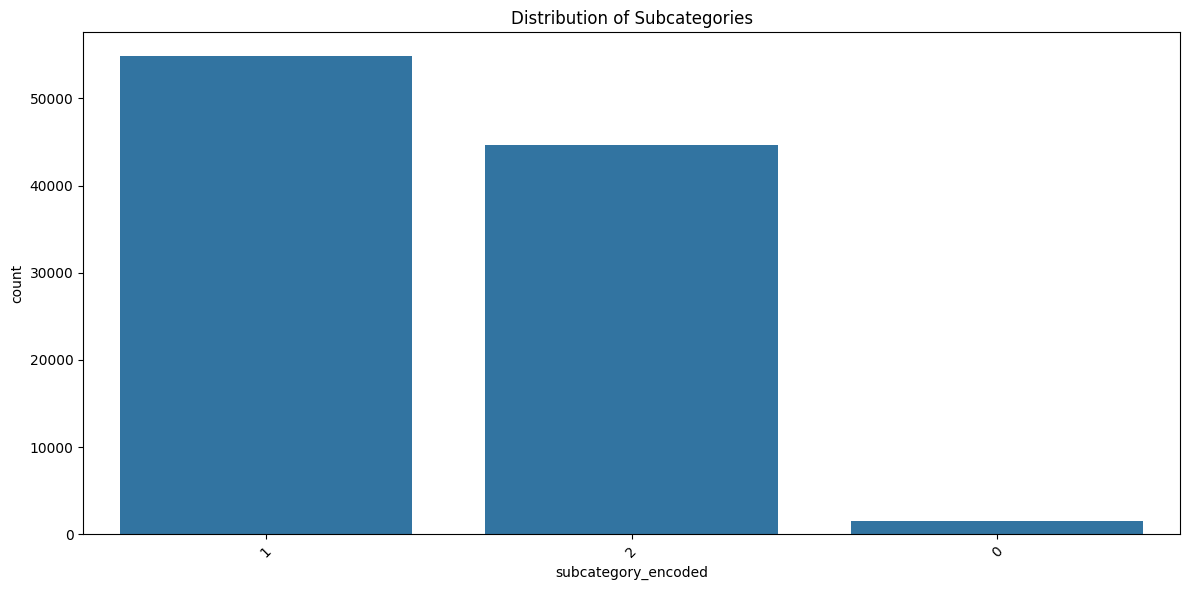

In [ ]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='subcategory_encoded', order=df['subcategory_encoded'].value_counts().index)
plt.xticks(rotation=45)
plt.title('Distribution of Subcategories')
plt.tight_layout()
plt.show()

dataset is not balanced hence we will perform smote and oversampling

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.impute import SimpleImputer

In [ ]:
X = df.drop(columns=['subcategory_encoded'])
y = df['subcategory_encoded']

In [ ]:
imputer = SimpleImputer(strategy='mean')
X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

In [ ]:
print("Before SMOTE:")
print(y_train.value_counts())
print("\nAfter SMOTE:")
print(pd.Series(y_train_balanced).value_counts())

Before SMOTE:
subcategory_encoded
1    43864
2    35755
0     1188
Name: count, dtype: int64

After SMOTE:
subcategory_encoded
1    43864
2    43864
0    43864
Name: count, dtype: int64


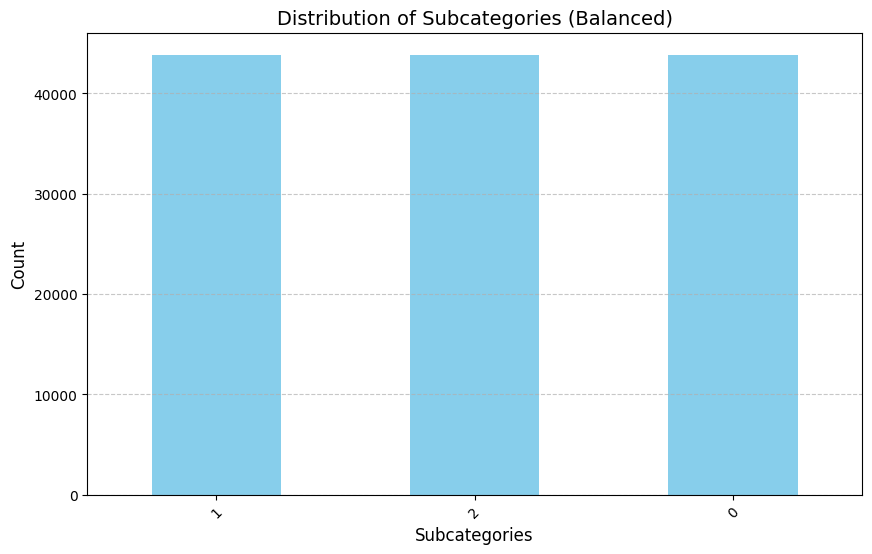

In [ ]:
plt.figure(figsize=(10, 6))
# Create balanced_data DataFrame
balanced_data = pd.DataFrame(X_train_balanced)  # Assuming X_train_balanced is a NumPy array
balanced_data['subcategory_encoded'] = y_train_balanced

balanced_data['subcategory_encoded'].value_counts().plot(kind='bar', color='skyblue')
plt.title('Distribution of Subcategories (Balanced)', fontsize=14)
plt.xlabel('Subcategories', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

to perform normalisation , we will first check variance for each column

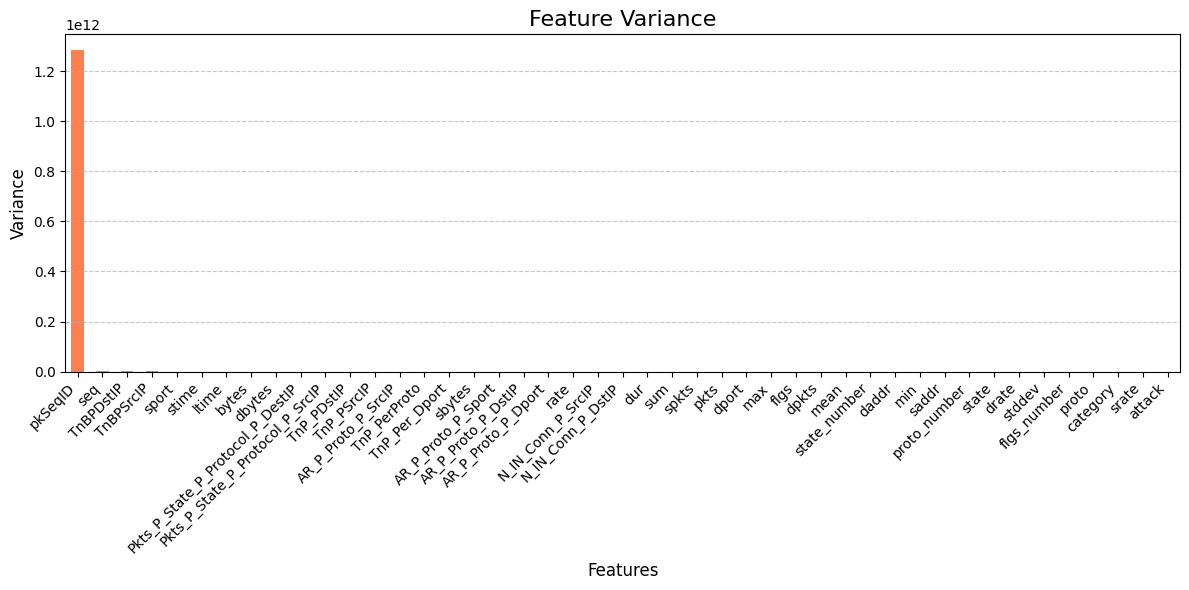

In [ ]:
features = balanced_data.drop(columns=['subcategory_encoded'])
variances = features.var()
plt.figure(figsize=(12, 6))
variances.sort_values(ascending=False).plot(kind='bar', color='coral')
plt.title('Feature Variance', fontsize=16)
plt.xlabel('Features', fontsize=12)
plt.ylabel('Variance', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler = StandardScaler()

In [ ]:
features=['TnBPSrcIP','TnBPDstIP']

In [ ]:
df[features] = scaler.fit_transform(df[features])

In [ ]:
print("All features have been standardized.")
print(df.describe())

All features have been standardized.
            pkSeqID         stime           flgs    flgs_number  \
count  1.010090e+05  1.010090e+05  101009.000000  101009.000000   
mean   1.291993e+06  1.528089e+09       2.188142       1.628182   
std    1.140327e+06  7.425475e+03       1.985724       0.756111   
min    1.000000e+00  1.528081e+09       0.000000       1.000000   
25%    3.498400e+04  1.528081e+09       0.000000       1.000000   
50%    1.021582e+06  1.528085e+09       4.000000       2.000000   
75%    2.023424e+06  1.528096e+09       4.000000       2.000000   
max    3.029146e+06  1.528099e+09       5.000000       6.000000   

               proto   proto_number          saddr          sport  \
count  101009.000000  101009.000000  101009.000000  101009.000000   
mean        1.442396       1.885030       1.019553   24686.495946   
std         0.496833       0.993334       1.042473   19081.276129   
min         0.000000       1.000000       0.000000      -1.000000   
25%         1.

In [ ]:
updated_variances = df.var()

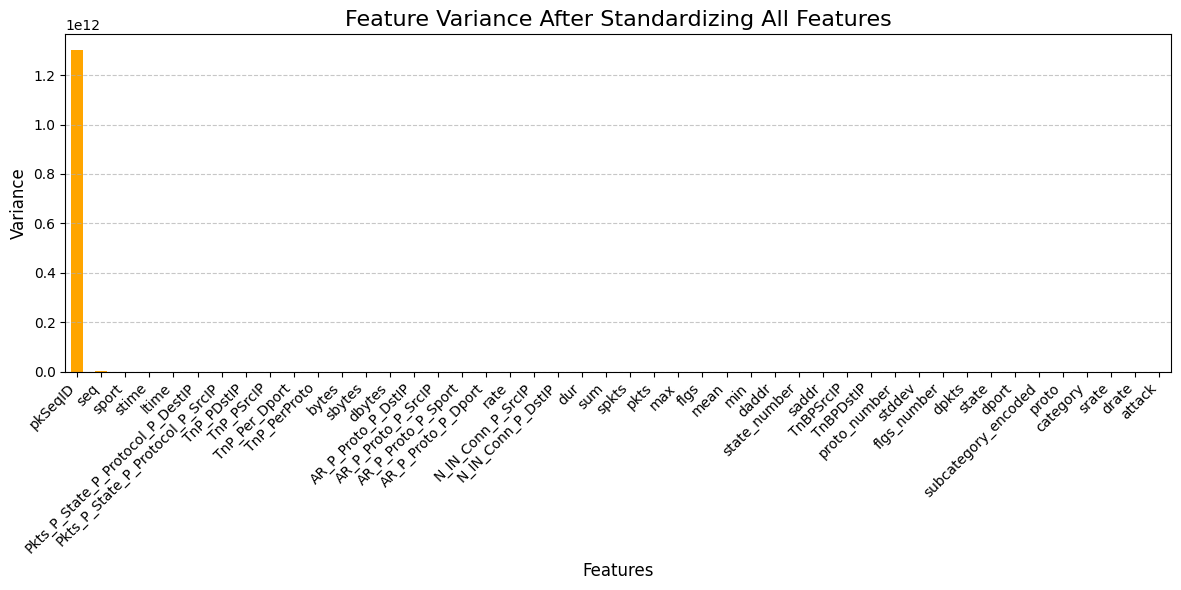

In [ ]:
plt.figure(figsize=(12, 6))
updated_variances.sort_values(ascending=False).plot(kind='bar', color='orange')
plt.title('Feature Variance After Standardizing All Features', fontsize=16)
plt.xlabel('Features', fontsize=12)
plt.ylabel('Variance', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

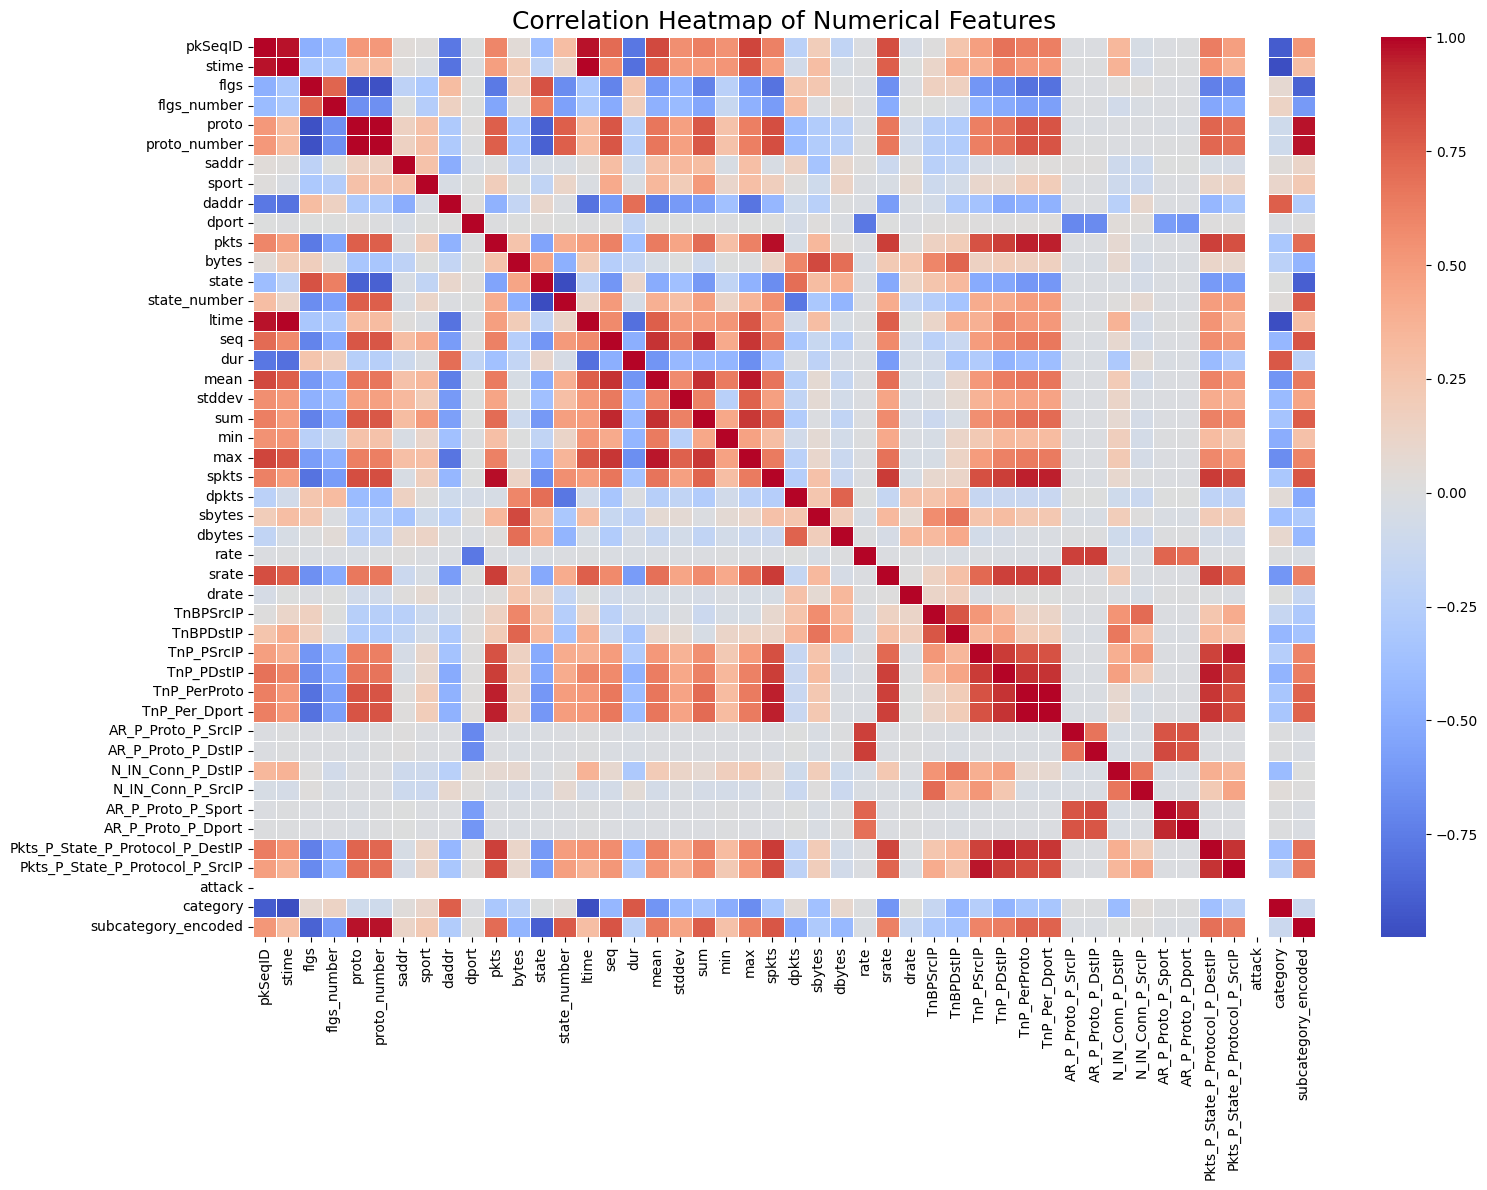

In [ ]:
corr_matrix = df.corr()
plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False, fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Numerical Features", fontsize=18)
plt.tight_layout()
plt.show()

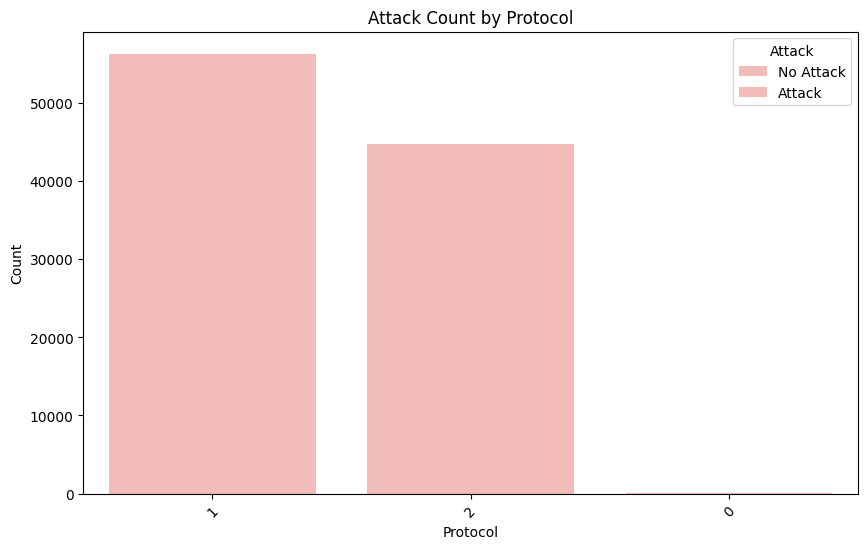

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(x='proto', hue='attack', data=df, palette='Pastel1', order=df['proto'].value_counts().index)
plt.title('Attack Count by Protocol')
plt.xlabel('Protocol')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Attack', labels=['No Attack', 'Attack'])
plt.show()

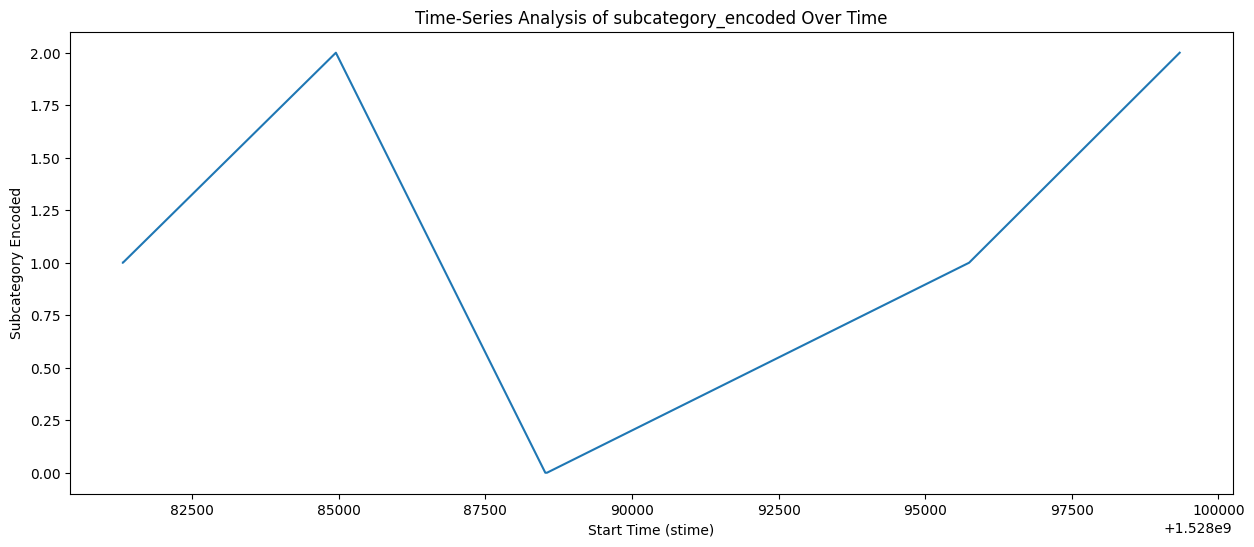

In [ ]:
plt.figure(figsize=(15, 6))
df_sorted = df.sort_values(by='stime')
sns.lineplot(x='stime', y='subcategory_encoded', data=df_sorted, ci=None)
plt.title('Time-Series Analysis of subcategory_encoded Over Time')
plt.xlabel('Start Time (stime)')
plt.ylabel('Subcategory Encoded')
plt.show()

feature selection using those three methods

In [ ]:
correlations = df.corr()['subcategory_encoded'].drop('subcategory_encoded')

In [ ]:
top_corr_features = correlations.abs().sort_values(ascending=False)

In [ ]:
print("Top correlated features with target:\n")
print(top_corr_features.head(10))

Top correlated features with target:

proto            0.973612
proto_number     0.973398
state            0.882631
flgs             0.872477
seq              0.793963
spkts            0.788587
state_number     0.772615
sum              0.767112
TnP_Per_Dport    0.743863
TnP_PerProto     0.743863
Name: subcategory_encoded, dtype: float64


In [ ]:
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold

In [ ]:
df_sampled = df.sample(n=5000, random_state=42)

In [ ]:
X = df_sampled.select_dtypes(include='number').drop(columns=['subcategory_encoded'])
y = df_sampled['subcategory_encoded']

In [ ]:
model = LogisticRegression(max_iter=1000)

In [ ]:
sfs = SequentialFeatureSelector(
    model,
    n_features_to_select=10,
    direction='forward',
    cv=StratifiedKFold(n_splits=3),
    n_jobs=-1
)

In [ ]:
df_sampled = df.sample(n=1000, random_state=42)  # Reduce sample size to 1000
X = df_sampled.drop(columns=['subcategory_encoded'])
y = df_sampled['subcategory_encoded']
# ... (Rest of your code using SFS) ...
sfs = SequentialFeatureSelector(
    model,
    n_features_to_select=5,  # Reduce the number of features to select
    direction='forward',
    cv=StratifiedKFold(n_splits=3),
    n_jobs=-1,
    scoring='f1_macro'  # Use a different scoring metric
)

In [ ]:
df_sampled = df.sample(n=1000, random_state=42)  # Reduce sample size to 1000
X = df_sampled.drop(columns=['subcategory_encoded'])
y = df_sampled['subcategory_encoded']
# ... (Rest of your code using SFS) ...
sfs = SequentialFeatureSelector(
    model,
    n_features_to_select=5,  # Reduce the number of features to select
    direction='forward',
    cv=StratifiedKFold(n_splits=3),
    n_jobs=-1,
    scoring='f1_macro'  # Use a different scoring metric
)
# Fit the SequentialFeatureSelector to the data
sfs.fit(X, y)  # This line is added to fit the SFS

selected_features = X.columns[sfs.get_support()].tolist()
print(" Features selected by Forward Selection:\n", selected_features)

 Features selected by Forward Selection:
 ['flgs', 'flgs_number', 'proto', 'proto_number', 'dbytes']


step 1: lets import libraries

In [ ]:
from sklearn.linear_model import LogisticRegressionCV
from sklearn.preprocessing import StandardScaler
import numpy as np

step 2: lets scale the features

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

step 3: lets perform elastic net regression method

In [ ]:
elastic = LogisticRegressionCV(
    penalty='elasticnet',
    solver='saga',
    l1_ratios=[0.9],
    Cs=[0.01, 0.1, 1],
    cv=5,
    scoring='accuracy',
    max_iter=5000,
    n_jobs=-1
)

step 4: lets fit the model

In [ ]:
elastic.fit(X_scaled, y)

LogisticRegressionCV(Cs=[0.01, 0.1, 1], cv=5, l1_ratios=[0.9], max_iter=5000,
                     n_jobs=-1, penalty='elasticnet', scoring='accuracy',
                     solver='saga')

step 5: i will have to be sure that only to get the non-zero significant coefficiants only

In [ ]:
coef = elastic.coef_[0]
selected_features = X.columns[np.abs(coef) > 0.01]

step 6: now we will display the selected features

In [ ]:
print(" Selected features by Elastic Net (filtered):")
print(selected_features.tolist())

 Selected features by Elastic Net (filtered):
['dbytes', 'drate']


NOW LETS TRAIN MY LOGISTIC REGRESSION MODEL

step 1: lets import accuracy library first

In [ ]:
from sklearn.metrics import accuracy_score

step 2: lets scale the features first

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

step 3: lets train the model

In [ ]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

step 4: lets predict and evaluate

In [ ]:
y_pred = model.predict(X_test_scaled)
acc = accuracy_score(y_test, y_pred)
print(f" Logistic Regression Accuracy: {acc:.4f}")

 Logistic Regression Accuracy: 1.0000


NOW I WILL HAVE TO PERFORM BAGGING ON THIS DATASET, LETS DO IT

step 1: importing libraries

In [ ]:
from sklearn.ensemble import BaggingClassifier

step 2: lets define our features

In [ ]:
X_full = df[selected_features]
y_full = df['subcategory_encoded']

In [ ]:
selected_featuress=['proto','state','state_number','proto_number','mean','max','stime','ltime','seq','stddev']

step 3: now we have to do test train split

In [ ]:
_train, X_test, y_train, y_test = train_test_split(X_full, y_full, test_size=0.2, random_state=42, stratify=y_full)

In [ ]:
X_train = X_train[selected_features]
X_test = X_test[selected_features]

step 4: now lets scale the features

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

step 5: initialize base model and bagging classifier

In [ ]:
base_model = LogisticRegression(max_iter=1000)
bagging_model = BaggingClassifier(
    estimator=base_model,
    n_estimators=10,
    max_samples=0.8,
    bootstrap=True,
    n_jobs=-1,
    random_state=42
)

step 6: lets fit the bagging model

In [ ]:
bagging_model.fit(X_train_scaled, y_train)

BaggingClassifier(estimator=LogisticRegression(max_iter=1000), max_samples=0.8,
                  n_jobs=-1, random_state=42)

step 7: now we will predict and evaluate

In [ ]:
y_pred_bag = bagging_model.predict(X_test_scaled)
bagging_acc = accuracy_score(y_test, y_pred_bag)
print(f" Bagging Accuracy (Logistic Regression): {bagging_acc:.4f}")

 Bagging Accuracy (Logistic Regression): 0.6559
